# Parte 1: Generación de resúmenes de noticias

In [14]:
import torch
import torch.nn as nn
import re, random, gc

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


PyTorch version: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
Device: cuda


In [15]:
# esto es para liberar memoria 
def liberar_gpu(*vars_a_borrar, mensaje=""):
    
    for obj in vars_a_borrar:
        try:
            if hasattr(obj, 'model'):       # Trainer de HuggingFace
                obj.model.cpu()
            elif hasattr(obj, 'cpu'):       # nn.Module o tensor
                obj.cpu()
        except Exception:
            pass
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        mem = torch.cuda.memory_reserved() / 1024**3
        print(f"{'[' + mensaje + '] ' if mensaje else ''}VRAM reservada tras limpieza: {mem:.2f} GB")



In [16]:
!pip install -q datasets transformers evaluate rouge_score sentencepiece

## Actividad 1 - Preguntas teóricas

### a) Limitaciones de una RNN vanilla en textos largos

Una RNN vanilla presenta dos limitaciones principales al procesar textos largos:

- **Vanishing/exploding gradients**: Durante el backpropagation a través del tiempo (BPTT), los gradientes se multiplican repetidamente por los pesos recurrentes. En secuencias largas, esto provoca que los gradientes se anulen o exploten, impidiendo que el modelo aprenda dependencias de largo alcance.

- **Cuello de botella de vector fijo**: El encoder comprime toda la secuencia de entrada en un único vector de contexto de longitud fija. Como señalan Bahdanau et al. [5], el rendimiento del encoder-decoder básico se deteriora rápidamente a medida que aumenta la longitud de la oración de entrada, ya que es difícil comprimir toda la información relevante en un vector de dimensión constante.

### b) Problema que resuelve el mecanismo de atención en Seq2Seq

El mecanismo de atención propuesto por Bahdanau et al. [5] resuelve el cuello de botella del vector de contexto fijo. En lugar de comprimir toda la secuencia fuente en un único vector, el modelo calcula un vector de contexto distinto para cada palabra objetivo generada, ponderando las anotaciones del encoder según su relevancia para el paso de decodificación actual. Esto permite que el modelo acceda selectivamente a partes relevantes de la secuencia fuente en cada paso, siendo especialmente útil en textos de noticias donde la información relevante puede estar distribuida a lo largo del artículo.


### c) Diferencia entre encoder-only y encoder-decoder; idoneidad para resúmenes

**Encoder-only (BERT)**: Procesa la secuencia de entrada bidireccionalmente y produce representaciones contextuales de cada token. Sin embargo, sus predicciones son independientes entre sí (no autorregresivas), por lo que no puede ser usado directamente para generación de texto.

**Encoder-decoder (BART [2], T5 [3])**: Combina un encoder bidireccional con un decoder autoregresivo de izquierda a derecha. El encoder construye representaciones ricas del texto de entrada, y el decoder genera el texto de salida token a token condicionado en dichas representaciones mediante cross-attention.

El modelo encoder-decoder es más apropiado para generación de resúmenes porque:

- La tarea requiere **comprensión** del documento fuente (encoder bidireccional) y **generación fluida** del resumen (decoder autoregresivo).
- Permite generar texto de longitud variable no presente en la entrada (resúmenes abstractivos).
- Raffel et al. [3] demuestran que la arquitectura encoder-decoder obtiene resultados estado del arte en CNN/DailyMail bajo métricas ROUGE, superando a modelos solo-encoder en tareas generativas.


### d) Métricas ROUGE y por qué se prefieren sobre accuracy

Las métricas ROUGE (*Recall-Oriented Understudy for Gisting Evaluation*) miden la superposición léxica entre el resumen generado y uno o más resúmenes de referencia:

- **ROUGE-1**: Superposición de unigramas entre el resumen generado y la referencia.
- **ROUGE-2**: Superposición de bigramas, capturando algo de fluidez local.
- **ROUGE-L**: Basada en la subsecuencia común más larga, considera el orden relativo de las palabras sin requerir contigüidad exacta.

ROUGE se usa en lugar de *accuracy* porque la generación de resúmenes es una tarea de salida estructurada y variable: no existe una única respuesta correcta, sino múltiples resúmenes válidos. La *accuracy* requeriría una correspondencia exacta entre la predicción y la referencia, lo cual es prácticamente imposible en texto libre. ROUGE cuantifica el grado de solapamiento léxico siendo una aproximación pragmática a la calidad del resumen. Raffel et al. [3] reportan ROUGE-2-F como métrica principal en CNN/DailyMail, encontrando alta correlación entre ROUGE-1, ROUGE-2 y ROUGE-L.

Cargamos CNN/DailyMail y tomamos el subconjunto recomendado.
Cada ejemplo tiene `article` (noticia) y `highlights` (resumen de referencia).

In [17]:
# Hiperparámetros
N_TRAIN, N_VAL, N_TEST = 10000, 1000, 500
MAX_VOCAB        = 30000   
MAX_ARTICLE_LEN  = 400     
MAX_SUMMARY_LEN  = 100     
EMBED_DIM        = 256
HIDDEN_DIM       = 512
BATCH_SIZE       = 32
EPOCHS           = 5
LR               = 1e-3
TEACHER_FORCING  = 0.5

Dispositivo: cuda


In [18]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

dataset = load_dataset("cnn_dailymail", "3.0.0")
train_data = dataset["train"].select(range(10000))
val_data   = dataset["validation"].select(range(1000))
test_data  = dataset["test"].select(range(500))

print(f"Train: {len(train_data)} ejemplos")
print(f"Val:   {len(val_data)} ejemplos")
print(f"Test:  {len(test_data)} ejemplos")
print(f"Campos: {train_data.column_names}")

Train: 10000 ejemplos
Val:   1000 ejemplos
Test:  500 ejemplos
Campos: ['article', 'highlights', 'id']


In [19]:
def mostrar_ejemplo(ejemplo, idx=None, max_chars=600):
    titulo = f"EJEMPLO {idx}" if idx is not None else "EJEMPLO"
    print("=" * 80)
    print(f"{titulo}")
    print("=" * 80)
    print("\n📰 ARTICLE:")
    art = ejemplo['article']
    print(art[:max_chars] + ("..." if len(art) > max_chars else ""))
    print(f"\n   (longitud total: {len(art.split())} palabras)")
    print("\n📝 HIGHLIGHTS (resumen de referencia):")
    print(ejemplo['highlights'])
    print(f"\n   (longitud: {len(ejemplo['highlights'].split())} palabras)")
    print()

for i in range(3):
    mostrar_ejemplo(train_data[i], idx=i)

EJEMPLO 0

📰 ARTICLE:
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," ...

   (longitud total: 455 palabras)

📝 HIGHLIGHTS (resumen de referencia):
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .

   (longitud: 41 palabras)

EJEMPLO 1

📰 ARTICLE:
Editor's note: In our Behind th

Artículos  - media: 620, mediana: 575, p95: 1184
Resúmenes  - media: 45, mediana: 45, p95: 57


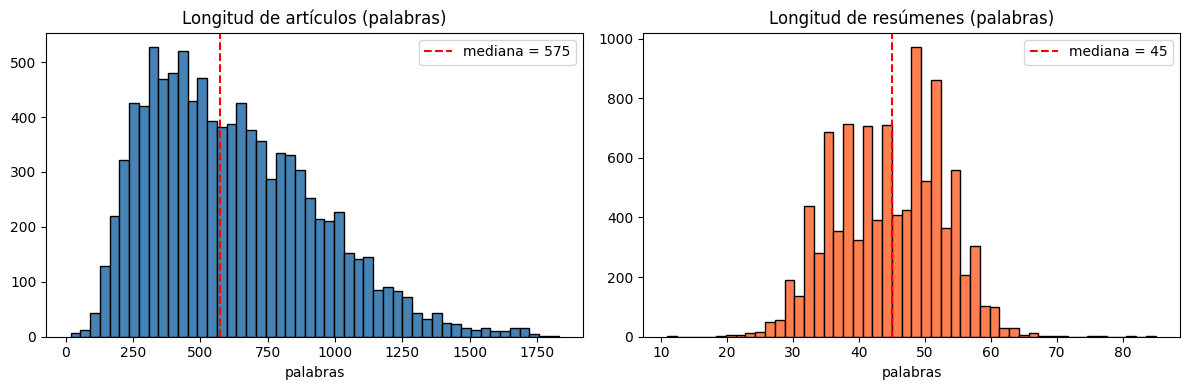

In [20]:
import numpy as np
import matplotlib.pyplot as plt

art_lens = [len(x['article'].split())    for x in train_data]
sum_lens = [len(x['highlights'].split()) for x in train_data]

print(f"Artículos  - media: {np.mean(art_lens):.0f}, mediana: {np.median(art_lens):.0f}, p95: {np.percentile(art_lens, 95):.0f}")
print(f"Resúmenes  - media: {np.mean(sum_lens):.0f}, mediana: {np.median(sum_lens):.0f}, p95: {np.percentile(sum_lens, 95):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(art_lens, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Longitud de artículos (palabras)')
axes[0].set_xlabel('palabras')
axes[0].axvline(np.median(art_lens), color='red', linestyle='--', label=f'mediana = {np.median(art_lens):.0f}')
axes[0].legend()

axes[1].hist(sum_lens, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Longitud de resúmenes (palabras)')
axes[1].set_xlabel('palabras')
axes[1].axvline(np.median(sum_lens), color='red', linestyle='--', label=f'mediana = {np.median(sum_lens):.0f}')
axes[1].legend()

plt.tight_layout(); plt.show()

## Actividad 2 - LSTM como *baseline*

### encoder-decoder

- El **encoder** (LSTM) lee el artículo y lo comprime en un estado oculto `(h, c)`.
- El **decoder** (LSTM) parte de ese estado y genera el resumen palabra por palabra.

El código base usa `forward(self, x)`, pero un encoder-decoder necesita la noticia (`src`)
y el resumen objetivo (`tgt`) durante el entrenamiento, así que ampliamos la firma.

In [21]:
# encoder - decoder
class LSTMSummarizer(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(LSTMSummarizer, self).__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.encoder   = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.decoder   = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc_out    = nn.Linear(hidden_dim, output_dim)

    def forward(self, src, tgt, teacher_forcing=0.5):
        # 1) el encoder comprime la noticia en (h, c)
        _, (h, c) = self.encoder(self.embedding(src))
        # 2) el decoder genera el resumen token por token
        batch, tgt_len = tgt.shape
        outputs = torch.zeros(batch, tgt_len, self.output_dim, device=tgt.device)
        inp = tgt[:, 0:1]                                  # token <sos>
        for t in range(1, tgt_len):
            out, (h, c) = self.decoder(self.embedding(inp), (h, c))
            logits = self.fc_out(out.squeeze(1))           # (batch, vocab)
            outputs[:, t] = logits
            top1 = logits.argmax(1, keepdim=True)
            inp = tgt[:, t:t+1] if random.random() < teacher_forcing else top1
        return outputs

    @torch.no_grad()
    def generate(self, src, max_len=MAX_SUMMARY_LEN):
        self.eval()
        _, (h, c) = self.encoder(self.embedding(src))
        inp = torch.full((src.size(0), 1), SOS_IDX, dtype=torch.long, device=src.device)
        ids = []
        for _ in range(max_len):
            out, (h, c) = self.decoder(self.embedding(inp), (h, c))
            top1 = self.fc_out(out.squeeze(1)).argmax(1)
            ids.append(top1)
            inp = top1.unsqueeze(1)
        return torch.stack(ids, dim=1)


### tokenizar / vocabulario / dataloaders

In [22]:
#tokenizar

from collections import Counter
from tqdm.auto import tqdm

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
SPECIALS = ["<pad>", "<unk>", "<sos>", "<eos>"]
_token_re = re.compile(r"[a-z0-9]+|[.,!?;:]")

def tokenize(text):
    return _token_re.findall(text.lower())

# contar frecuencias y armar el vocabulario 
counter = Counter()
for ej in tqdm(train_data, desc="Vocabulario"):
    counter.update(tokenize(ej["article"]))
    counter.update(tokenize(ej["highlights"]))

itos = SPECIALS + [w for w, _ in counter.most_common(MAX_VOCAB)]   # índice -> palabra
stoi = {w: i for i, w in enumerate(itos)}                          # palabra -> índice
VOCAB_SIZE = len(itos)
print("Tamaño del vocabulario:", VOCAB_SIZE)

Vocabulario:   0%|          | 0/10000 [00:00<?, ?it/s]

Tamaño del vocabulario: 30004


In [23]:
# numericalizar y dataloaders

def encode_article(text):
    ids = [stoi.get(t, UNK_IDX) for t in tokenize(text)[:MAX_ARTICLE_LEN]]
    return ids or [UNK_IDX]

def encode_summary(text):
    ids = [stoi.get(t, UNK_IDX) for t in tokenize(text)[:MAX_SUMMARY_LEN - 2]]
    return [SOS_IDX] + ids + [EOS_IDX]

class SummaryDataset(Dataset):
    def __init__(self, split):
        self.src = [encode_article(e["article"])  for e in tqdm(split, desc="Numericalizando")]
        self.tgt = [encode_summary(e["highlights"]) for e in split]
    def __len__(self):  return len(self.src)
    def __getitem__(self, i):  return self.src[i], self.tgt[i]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    srcs = pad_sequence([torch.tensor(s) for s in srcs], batch_first=True, padding_value=PAD_IDX)
    tgts = pad_sequence([torch.tensor(t) for t in tgts], batch_first=True, padding_value=PAD_IDX)
    return srcs, tgts

train_loader = DataLoader(SummaryDataset(train_data), batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(SummaryDataset(val_data),   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

xb, yb = next(iter(train_loader))
print("Lote artículos:", xb.shape, "| Lote resúmenes:", yb.shape)

Numericalizando:   0%|          | 0/10000 [00:00<?, ?it/s]

Numericalizando:   0%|          | 0/1000 [00:00<?, ?it/s]

Lote artículos: torch.Size([32, 400]) | Lote resúmenes: torch.Size([32, 70])


In [24]:
model_lstm = LSTMSummarizer(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, VOCAB_SIZE).to(device)
print(model_lstm)

LSTMSummarizer(
  (embedding): Embedding(30004, 256, padding_idx=0)
  (encoder): LSTM(256, 512, batch_first=True)
  (decoder): LSTM(256, 512, batch_first=True)
  (fc_out): Linear(in_features=512, out_features=30004, bias=True)
)


### Entrenar

In [25]:
model = model_lstm
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def run_epoch(loader, train):
    model.train() if train else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in tqdm(loader, leave=False):
            src, tgt = src.to(device), tgt.to(device)
            outputs = model(src, tgt, TEACHER_FORCING if train else 0.0)
            loss = criterion(outputs[:, 1:].reshape(-1, VOCAB_SIZE),
                             tgt[:, 1:].reshape(-1))           # descartamos <sos>
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item()
    return total / len(loader)

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    print(f"Época {epoch}  |  pérdida train {tr:.3f}  |  pérdida val {va:.3f}")

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Época 1  |  pérdida train 7.274  |  pérdida val 7.066


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

Época 4  |  pérdida train 6.540  |  pérdida val 7.128


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Época 5  |  pérdida train 6.403  |  pérdida val 7.136


In [26]:
model_lstm    = torch.load("model_lstm.pt",    map_location=device) if not 'model_lstm'    in dir() else model_lstm     # noqa

In [27]:
torch.save(model_lstm.state_dict(), "model_lstm.pt")
print("model_lstm.pt guardado ✓")

liberar_gpu(optimizer, mensaje="Después de LSTM") #libero memoria

model_lstm.pt guardado ✓
[Después de LSTM] VRAM reservada tras limpieza: 0.74 GB


### Resumenes

In [28]:
# resumenes

def ids_to_text(ids):
    palabras = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            palabras.append(itos[i])
    return " ".join(palabras)

def resumir(articulo):
    ids = torch.tensor([encode_article(articulo)], device=device)
    return ids_to_text(model.generate(ids)[0])

# ejemplos
for k in range(3):
    ej = val_data[k]
    print("=" * 80)
    print(f"EJEMPLO {k+1}")
    print("Artículo (inicio):", ej["article"][:300].replace("\n", " "), "...")
    print("\nResumen de referencia:", ej["highlights"].replace("\n", " "))
    print("\nResumen generado:", resumir(ej["article"]) or "[vacío]")
    print()

EJEMPLO 1
Artículo (inicio): (CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thoug ...

Resumen de referencia: Zully Broussard decided to give a kidney to a stranger . A new computer program helped her donation spur transplants for six kidney patients .

Resumen generado: new : , of , , , , , , . . . . . . . . , , , , . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

EJEMPLO 2
Artículo (inicio): (CNN)On the 6th of April 1996, San Jose Clash and DC United strode out in front of 31,683 expectant fans at the Spartan Stadium in San Jose, California. The historic occasion was the first ever Major League Soccer match -- a brave new dawn for the world's favorite sport in a land its charms had yet  ...

Resumen de referencia: 

### Discusión 

Al revisar los resúmenes generados suelen verse: **frases genéricas**, **repeticiones**,
**pérdida de nombres y cifras** (aparecen como `<unk>`) y resúmenes poco fieles al artículo.

**Por qué ocurre, según la arquitectura usada:**

1. **Cuello de botella de información.** Toda la noticia se comprime en un único vector de
   tamaño fijo. Para artículos largos es imposible conservar todos los detalles: el decoder
   solo ve un resumen borroso de la entrada. Esta es la limitación central y es justamente
   lo que el **mecanismo de atención** (próxima actividad) viene a resolver.
2. **Truncamiento.** El artículo se corta a `MAX_ARTICLE_LEN` tokens; el resto se pierde.
3. **Vocabulario cerrado.** Las palabras raras (nombres, números) van a `<unk>` y el modelo
   no puede reproducirlas.
4. **Exposición sesgada.** Con teacher forcing el modelo entrena viendo el token correcto,
   pero en inferencia depende de sus propias predicciones; un error temprano se arrastra.
5. **Datos y cómputo limitados.** Solo usamos 10.000 ejemplos y pocas épocas para caber en
   Colab; más entrenamiento ayuda, pero no elimina el cuello de botella estructural.

**Conclusión.** El baseline aprende la *forma* de un resumen, pero su fidelidad es baja
porque comprime toda la noticia en un solo vector. Incorporar atención permite que el
decoder consulte distintas partes del artículo en cada paso, atacando directamente este
problema.

> Ajusta la redacción de las observaciones a lo que realmente veas al ejecutar el notebook.

## Actividad 3 - Seq2seq con atención 

In [29]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, (h, c) = self.lstm(emb)
        # outputs: (batch, len_articulo, hidden) -> un vector por palabra del artículo
        # (h, c): estado oculto final
        return outputs, (h, c)


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden)  -> estado actual del decoder
        # encoder_outputs: (batch, len_articulo, hidden)
        src_len = encoder_outputs.size(1)
        hidden_rep = hidden.unsqueeze(1).repeat(1, src_len, 1)            # (batch, len, hidden)
        # score de atención para cada posición del artículo
        energy = torch.tanh(self.attn(torch.cat((hidden_rep, encoder_outputs), dim=2)))
        scores = self.v(energy).squeeze(2)                               # (batch, len)
        weights = torch.softmax(scores, dim=1)                           # pesos (softmax)
        # vector de contexto = suma ponderada de los estados del encoder
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (batch, hidden)
        return weights, context


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = Attention(hidden_dim)
        self.lstm = nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, x, hidden, encoder_outputs):
        # x: (batch, 1) un token   |   hidden: (h, c)
        h, c = hidden
        emb = self.embedding(x)                                          # (batch, 1, embed)
        weights, context = self.attention(h[-1], encoder_outputs)        # usa Attention
        lstm_in = torch.cat((emb, context.unsqueeze(1)), dim=2)          # embed + contexto
        out, (h, c) = self.lstm(lstm_in, (h, c))
        out = out.squeeze(1)                                             # (batch, hidden)
        pred = self.fc_out(torch.cat((out, context), dim=1))             # (batch, vocab)
        return pred, (h, c), weights


In [30]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing=0.5):
        encoder_outputs, hidden = self.encoder(src)
        batch, tgt_len = tgt.shape
        vocab = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch, tgt_len, vocab, device=tgt.device)
        inp = tgt[:, 0:1]                                                # <sos>
        for t in range(1, tgt_len):
            pred, hidden, _ = self.decoder(inp, hidden, encoder_outputs)
            outputs[:, t] = pred
            top1 = pred.argmax(1, keepdim=True)
            inp = tgt[:, t:t+1] if random.random() < teacher_forcing else top1
        return outputs

    @torch.no_grad()
    def generate(self, src, max_len=MAX_SUMMARY_LEN):
        self.eval()
        encoder_outputs, hidden = self.encoder(src)
        inp = torch.full((src.size(0), 1), SOS_IDX, dtype=torch.long, device=src.device)
        ids, attn = [], []
        for _ in range(max_len):
            pred, hidden, weights = self.decoder(inp, hidden, encoder_outputs)
            top1 = pred.argmax(1)
            ids.append(top1)
            attn.append(weights)                                         # (batch, len_articulo)
            inp = top1.unsqueeze(1)
        # ids: (batch, max_len)   attn: (batch, max_len, len_articulo)
        return torch.stack(ids, dim=1), torch.stack(attn, dim=1)

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
model_seq2seq   = Seq2Seq(encoder, decoder).to(device)
print(model_seq2seq)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(30004, 256, padding_idx=0)
    (lstm): LSTM(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(30004, 256, padding_idx=0)
    (attention): Attention(
      (attn): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (lstm): LSTM(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=30004, bias=True)
  )
)


### Entrenamiento

In [31]:
model = model_seq2seq
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def run_epoch(loader, train):
    model.train() if train else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in tqdm(loader, leave=False):
            src, tgt = src.to(device), tgt.to(device)
            outputs = model(src, tgt, TEACHER_FORCING if train else 0.0)
            loss = criterion(outputs[:, 1:].reshape(-1, VOCAB_SIZE),
                             tgt[:, 1:].reshape(-1))
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item()
    return total / len(loader)

# --- ejecución: loop de entrenamiento ---
for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    print(f"Época {epoch}  |  pérdida train {tr:.3f}  |  pérdida val {va:.3f}")

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Época 1  |  pérdida train 7.219  |  pérdida val 7.060


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

Época 4  |  pérdida train 5.800  |  pérdida val 6.938


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Época 5  |  pérdida train 5.335  |  pérdida val 7.040


In [32]:
torch.save(model_lstm.state_dict(), "model_seq2seq.pt")
liberar_gpu(optimizer, mensaje="Después de Seq2seq") #libero memoria

[Después de Seq2seq] VRAM reservada tras limpieza: 1.48 GB


In [33]:
# esto es para ir limpiando la memoria 
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [34]:
model_seq2seq = torch.load("model_seq2seq.pt", map_location=device) if not 'model_seq2seq' in dir() else model_seq2seq  # noqa

In [35]:
def ids_to_text(ids):
    palabras = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            palabras.append(itos[i])
    return " ".join(palabras)

def resumir(articulo):
    ids = torch.tensor([encode_article(articulo)], device=device)
    gen_ids, _ = model.generate(ids)
    return ids_to_text(gen_ids[0])

# ejemplos
for k in range(3):
    ej = val_data[k]
    print("=" * 80)
    print(f"EJEMPLO {k+1}")
    print("Artículo (inicio):", ej["article"][:300].replace("\n", " "), "...")
    print("\nResumen de referencia:", ej["highlights"].replace("\n", " "))
    print("\nResumen generado (con atención):", resumir(ej["article"]) or "[vacío]")
    print()

EJEMPLO 1
Artículo (inicio): (CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thoug ...

Resumen de referencia: Zully Broussard decided to give a kidney to a stranger . A new computer program helped her donation spur transplants for six kidney patients .

Resumen generado (con atención): <unk> <unk> , the <unk> , the to . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

EJEMPLO 2
Artículo (inicio): (CNN)On the 6th of April 1996, San Jose Clash and DC United strode out in front of 31,683 expectant fans at the Spartan Stadium in San Jose, California. The historic occasion was the first ever Major League Soccer match -- a brave new dawn for the world's favorite sport in a land its charms had yet  ...

Resumen de referencia: The 20t

### a) Comparar cualitativamente los resúmenes generados con los de la Actividad 2.

En términos de pérdida, el modelo con atención muestra una reducción progresiva durante el entrenamiento (de ~7.2 a ~5.3 en 5 épocas), lo cual indica que efectivamente está aprendiendo algo. Sin embargo, la pérdida de validación se mantiene relativamente estable cerca de 7.0 (inclusive sugiere que va en aumento), lo que sugiere que el modelo no está generalizando bien y podría estar sobreajustando. 

En cuanto a los resúmenes generados, la calidad es bastante pobre en ambos modelos. En los tres ejemplos se observan secuencias repetitivas de <unk> y puntos, lo que indica que el modelo está colapsando hacia los tokens más frecuentes del vocabulario en lugar de generar texto coherente. En ese sentido, no hay una mejora muy evidente respecto a la Actividad 2. La diferencia teórica es que el modelo con atención debería ser capaz de "mirar" partes relevantes del artículo al generar cada palabra del resumen, pero ese mecanismo no alcanza a desarrollarse correctamente.

### b) Visualizar los pesos de atención para al menos 3 noticias del conjunto de validación. Interprete qué partes del texto está mirando el modelo al generar cada palabra del resumen.

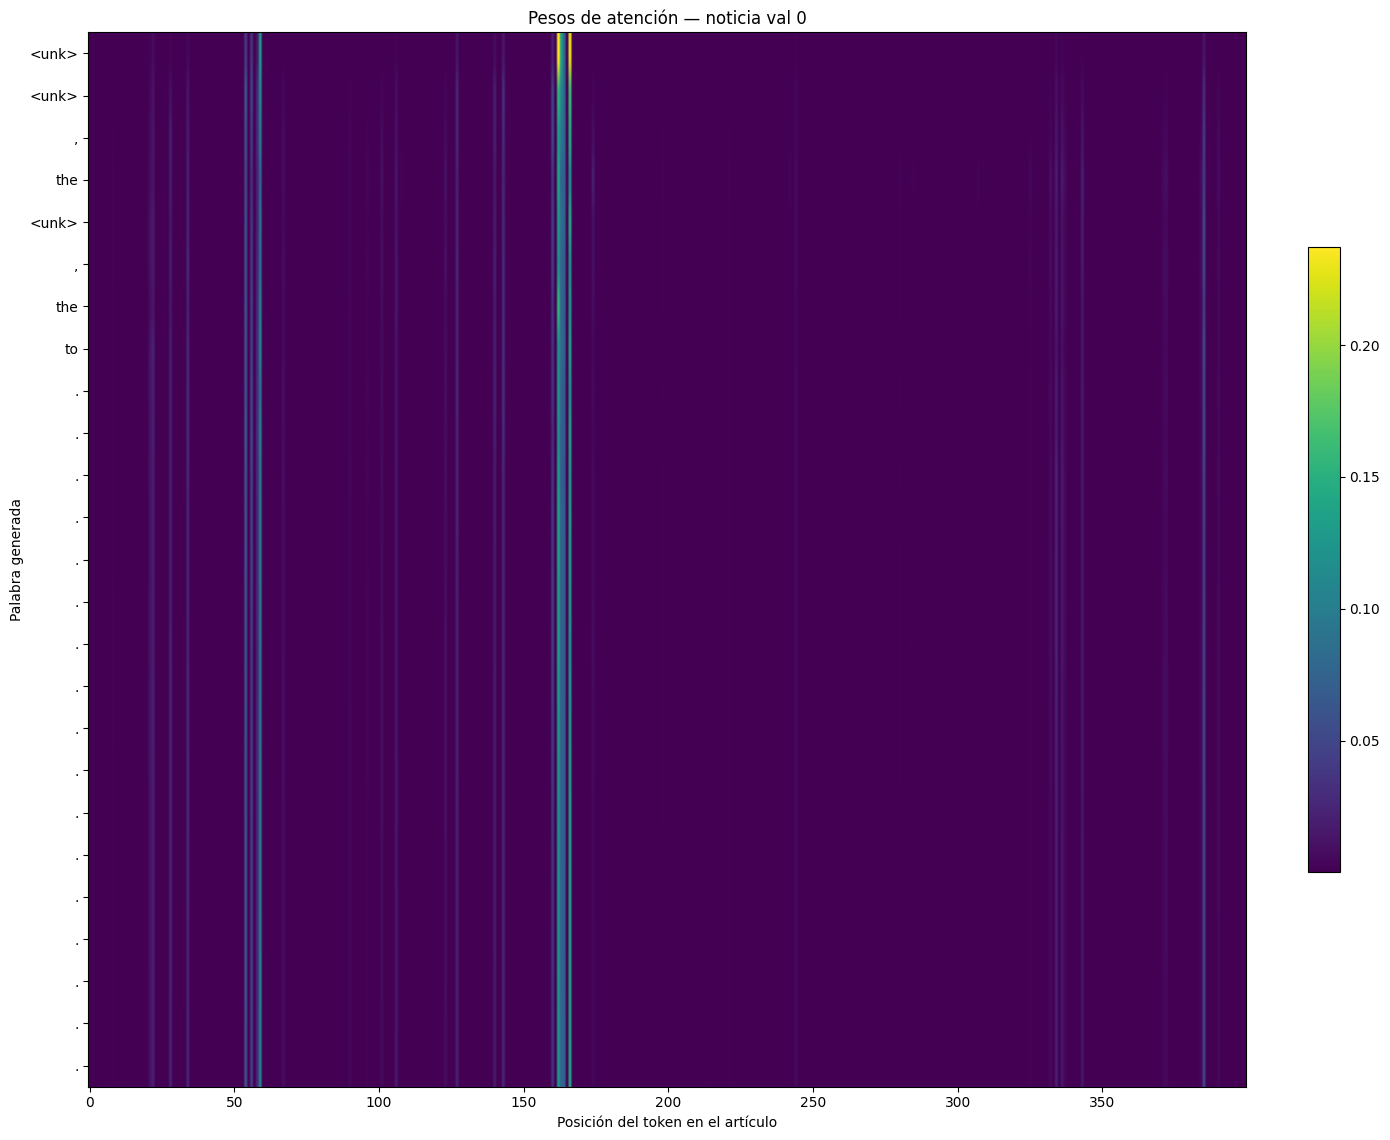

Noticia val 0 — token del artículo más atendido por cada palabra generada:
  '<unk>'  ->  '<unk>'  (posición 162, peso 0.24)
  '<unk>'  ->  'was'  (posición 166, peso 0.16)
  ','  ->  'was'  (posición 166, peso 0.15)
  'the'  ->  '<unk>'  (posición 162, peso 0.14)
  '<unk>'  ->  'was'  (posición 166, peso 0.14)
  ','  ->  'was'  (posición 166, peso 0.12)
  'the'  ->  '<unk>'  (posición 162, peso 0.15)
  'to'  ->  'was'  (posición 166, peso 0.14)
  '.'  ->  '<unk>'  (posición 162, peso 0.12)
  '.'  ->  'was'  (posición 166, peso 0.14)
  '.'  ->  '<unk>'  (posición 162, peso 0.13)
  '.'  ->  '<unk>'  (posición 162, peso 0.14)
  '.'  ->  '<unk>'  (posición 162, peso 0.13)
  '.'  ->  '<unk>'  (posición 162, peso 0.13)
  '.'  ->  '<unk>'  (posición 162, peso 0.13)
  '.'  ->  '<unk>'  (posición 162, peso 0.13)
  '.'  ->  'was'  (posición 166, peso 0.13)
  '.'  ->  'was'  (posición 166, peso 0.13)
  '.'  ->  'was'  (posición 166, peso 0.13)
  '.'  ->  'was'  (posición 166, peso 0.13)
  '.'  -

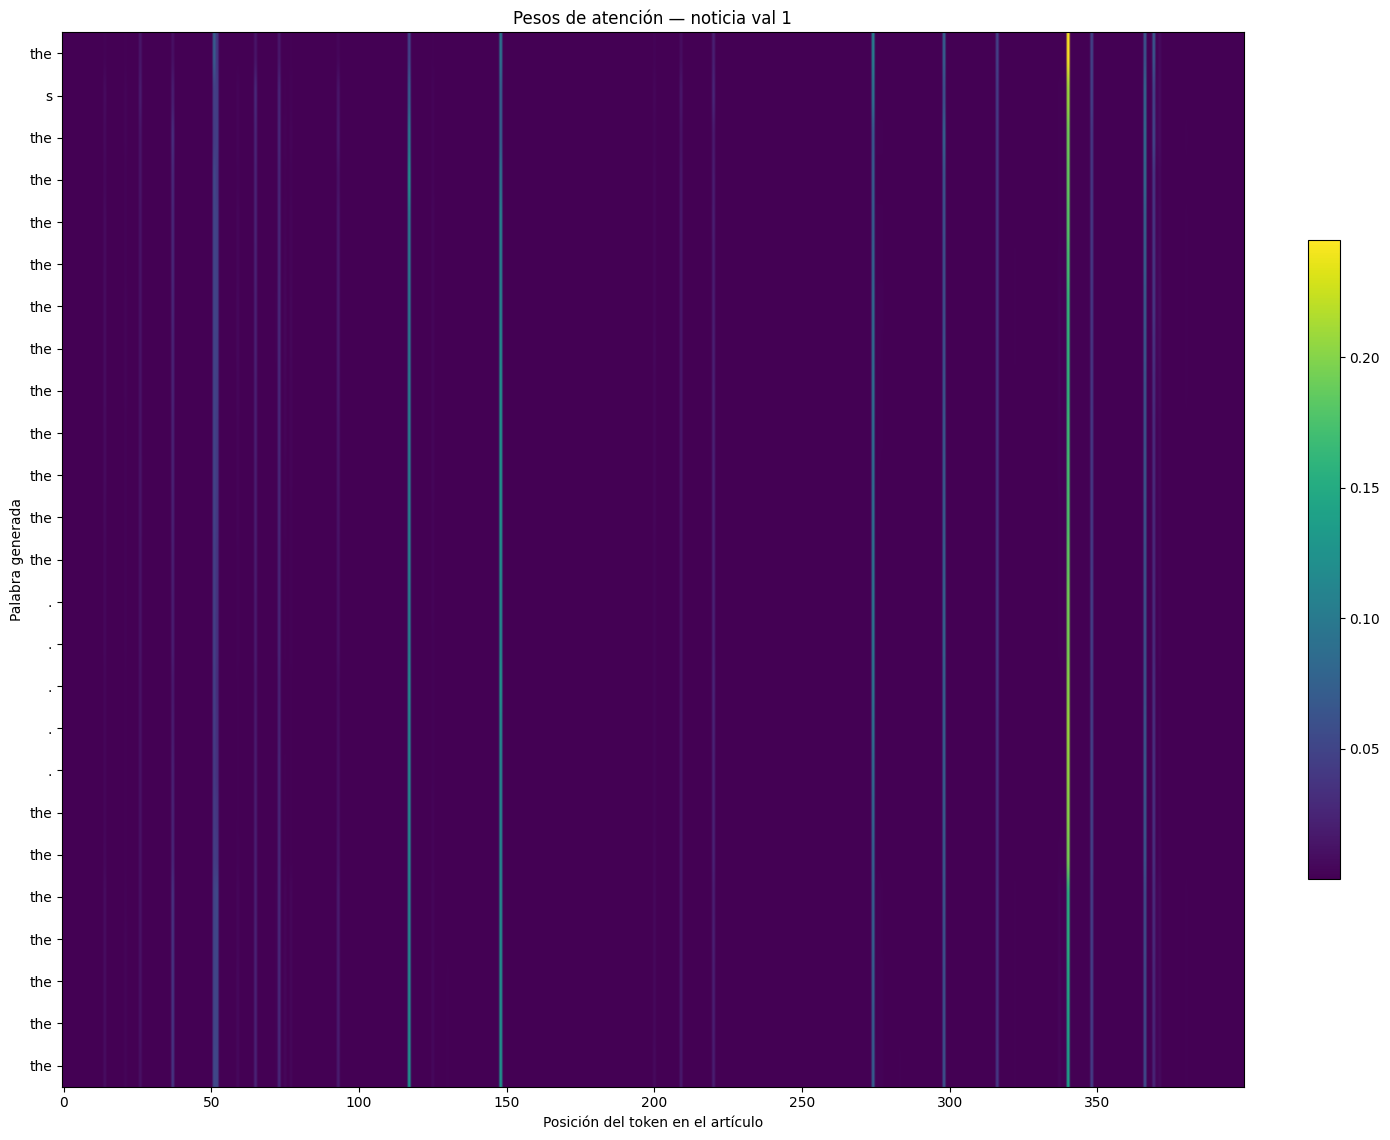

Noticia val 1 — token del artículo más atendido por cada palabra generada:
  'the'  ->  'president'  (posición 340, peso 0.24)
  's'  ->  'president'  (posición 340, peso 0.21)
  'the'  ->  'president'  (posición 340, peso 0.19)
  'the'  ->  'president'  (posición 340, peso 0.19)
  'the'  ->  'president'  (posición 340, peso 0.18)
  'the'  ->  'president'  (posición 340, peso 0.17)
  'the'  ->  'president'  (posición 340, peso 0.16)
  'the'  ->  'president'  (posición 340, peso 0.16)
  'the'  ->  'president'  (posición 340, peso 0.16)
  'the'  ->  'president'  (posición 340, peso 0.17)
  'the'  ->  'president'  (posición 340, peso 0.17)
  'the'  ->  'president'  (posición 340, peso 0.18)
  'the'  ->  'president'  (posición 340, peso 0.18)
  '.'  ->  'president'  (posición 340, peso 0.19)
  '.'  ->  'president'  (posición 340, peso 0.19)
  '.'  ->  'president'  (posición 340, peso 0.20)
  '.'  ->  'president'  (posición 340, peso 0.21)
  '.'  ->  'president'  (posición 340, peso 0.21)
 

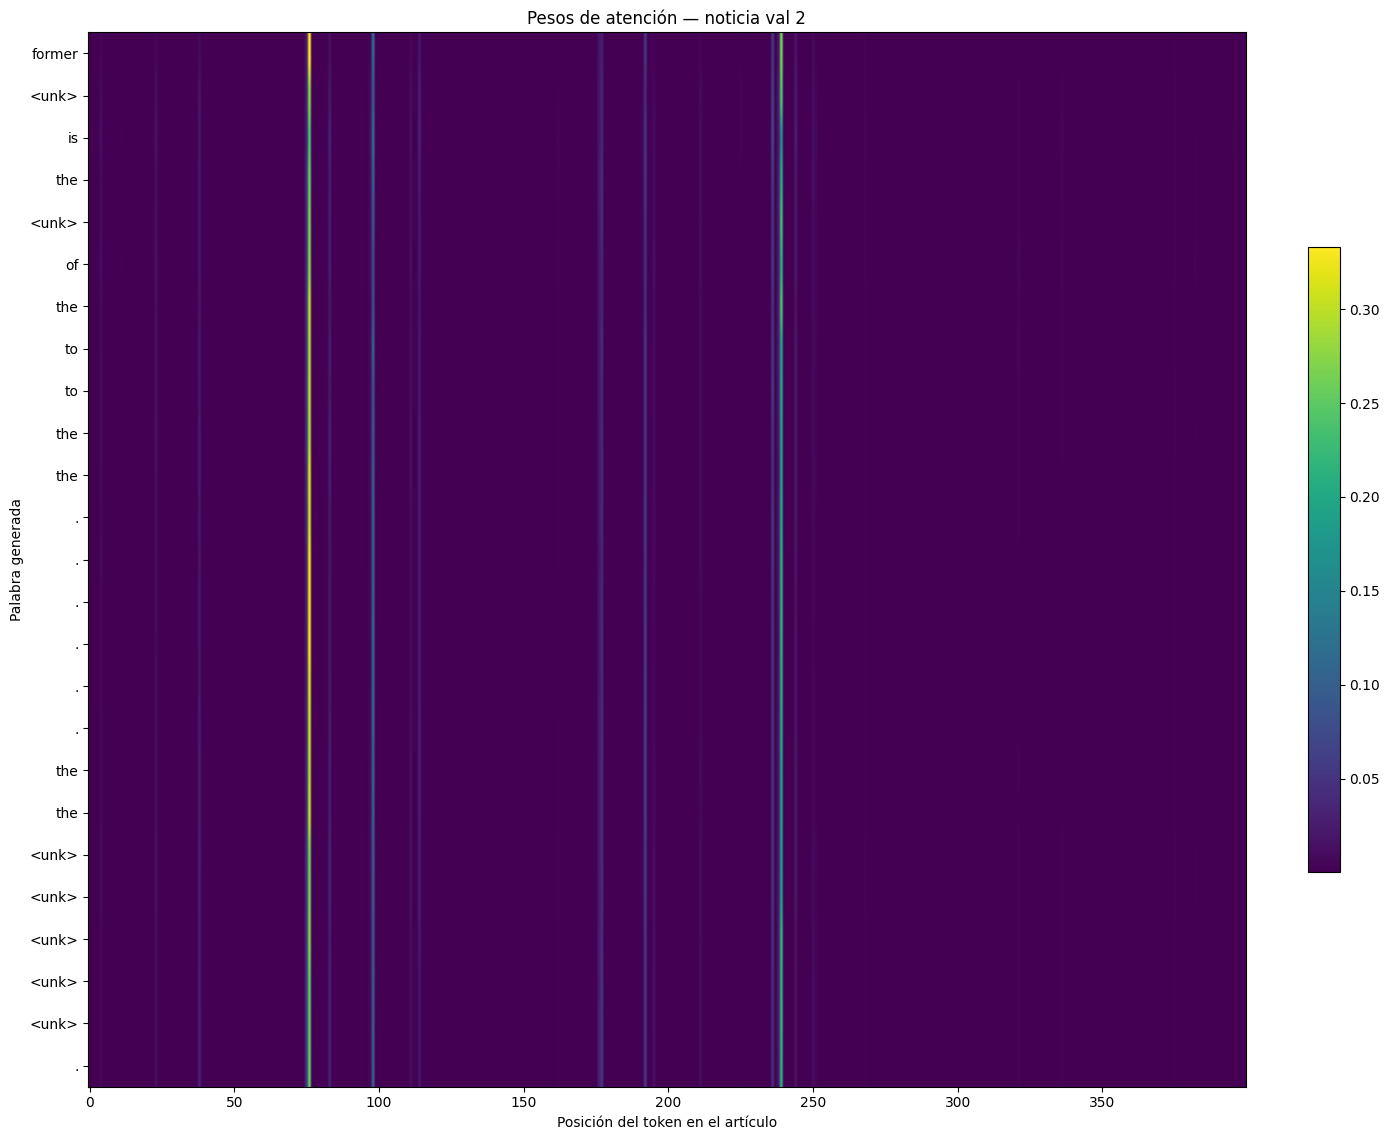

Noticia val 2 — token del artículo más atendido por cada palabra generada:
  'former'  ->  'was'  (posición 76, peso 0.33)
  '<unk>'  ->  'was'  (posición 76, peso 0.27)
  'is'  ->  'was'  (posición 76, peso 0.24)
  'the'  ->  'was'  (posición 76, peso 0.25)
  '<unk>'  ->  'was'  (posición 76, peso 0.26)
  'of'  ->  'was'  (posición 76, peso 0.27)
  'the'  ->  'was'  (posición 76, peso 0.30)
  'to'  ->  'was'  (posición 76, peso 0.29)
  'to'  ->  'was'  (posición 76, peso 0.30)
  'the'  ->  'was'  (posición 76, peso 0.29)
  'the'  ->  'was'  (posición 76, peso 0.31)
  '.'  ->  'was'  (posición 76, peso 0.31)
  '.'  ->  'was'  (posición 76, peso 0.32)
  '.'  ->  'was'  (posición 76, peso 0.32)
  '.'  ->  'was'  (posición 76, peso 0.32)
  '.'  ->  'was'  (posición 76, peso 0.31)
  '.'  ->  'was'  (posición 76, peso 0.30)
  'the'  ->  'was'  (posición 76, peso 0.29)
  'the'  ->  'was'  (posición 76, peso 0.30)
  '<unk>'  ->  'was'  (posición 76, peso 0.26)
  '<unk>'  ->  'was'  (posición 

In [36]:
# visualizar los pesos de atención 

def visualizar_atencion(idx, max_palabras=25):
    ej = val_data[idx]
    src_ids = encode_article(ej["article"])
    gen_ids, attn = model.generate(torch.tensor([src_ids], device=device))
    gen_ids = gen_ids[0].tolist()
    attn = attn[0].cpu()                                   # (max_len, len_articulo)

    # recortar la salida en <eos>
    L = gen_ids.index(EOS_IDX) if EOS_IDX in gen_ids else len(gen_ids)
    L = max(min(L, max_palabras), 1)
    gen_words = [itos[i] for i in gen_ids[:L]]
    src_words = [itos[i] for i in src_ids]
    attn = attn[:L, :len(src_ids)]

    # heatmap
    fig, ax = plt.subplots(figsize=(14, 0.4 * L + 1.5))
    im = ax.imshow(attn, aspect="auto", cmap="viridis")
    ax.set_yticks(range(L)); ax.set_yticklabels(gen_words)
    ax.set_xlabel("Posición del token en el artículo")
    ax.set_ylabel("Palabra generada")
    ax.set_title(f"Pesos de atención — noticia val {idx}")
    fig.colorbar(im, ax=ax, fraction=0.025)
    plt.tight_layout(); plt.show()

    # interpretación textual
    print(f"Noticia val {idx} — token del artículo más atendido por cada palabra generada:")
    for t, w in enumerate(gen_words):
        pos = attn[t].argmax().item()
        print(f"  '{w}'  ->  '{src_words[pos]}'  (posición {pos}, peso {attn[t, pos]:.2f})")
    print()

for idx in range(3):
    visualizar_atencion(idx)

Los heatmaps muestran, para cada palabra generada, qué tan fuerte es la atención sobre cada posición del artículo de entrada. Lo ideal sería ver algún tipo de estructura diagonal o al menos variación por fila, lo que indicaría que el modelo atiende a distintas partes del artículo según qué token está generando.
Sin embargo, en ambas noticias se observa que la atención está casi siempre concentrada en las mismas 2 o 3 posiciones del artículo, independientemente de qué palabra se esté generando. Esto se ve como columnas verticales brillantes en el heatmap, en lugar de una distribución que cambie por fila.
En val_0 hay un pico muy marcado alrededor de la posición 158, que domina la atención para prácticamente todas las palabras generadas. En la noticia val_2 el peak principal está cerca de la posición 75, con algo más de actividad en otras columnas, pero el patrón sigue siendo muy similar.
Esto sugiere que el mecanismo de atención no aprendió a distribuirse correctamente sobre el artículo. El modelo parece "fijarse" en ciertos tokens del encoder de forma casi constante, lo que es consistente con el hecho de que los resúmenes generados también son degenerados. Con más épocas de entrenamiento y posiblemente un vocabulario más amplio, se esperaría que la atención empezara a mostrar más variación y los resúmenes mejorasen.

## Actividad 4 - Fine-tuning con BART y T5

In [37]:
import warnings
warnings.filterwarnings("ignore")

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset
from rouge_score import rouge_scorer
import numpy as np
import pandas as pd

In [38]:
#from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
## BART
#tokenizer_bart = AutoTokenizer.from_pretrained("facebook/bart-base") model_bart = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-base")
## T5 (requiere prefijo en el input)
#tokenizer_t5 = AutoTokenizer.from_pretrained("t5-small") model_t5 = AutoModelForSeq2SeqLM.from_pretrained("t5-small") # Formato de entrada T5: "summarize: " + texto_de_la_noticia

In [39]:
MAX_SOURCE_LEN      = 512
MAX_TARGET_LEN      = 128
BATCH_SIZE_HF       = 8       # por dispositivo
GRAD_ACC_STEPS      = 4       # batch efectivo = 32 (igual al baseline)
NUM_EPOCHS_HF       = 3
WARMUP_RATIO        = 0.10
WEIGHT_DECAY        = 0.01
FP16                = torch.cuda.is_available()

LR_BART = 3e-5
LR_T5   = 5e-5

T5_PREFIX = "summarize: "    

print(f"FP16={FP16}  |  batch efectivo={BATCH_SIZE_HF * GRAD_ACC_STEPS}")

FP16=True  |  batch efectivo=32


In [40]:
# Funcion de tokenizacion para HuggingFace

def make_hf_dataset(raw_split, tokenizer, prefix=""):
    """
    Tokeniza un split de CNN/DM con `tokenizer`.
    `prefix` es el texto que T5 necesita anteponer (p.ej. 'summarize: ').
    Para BART se deja vacío.
    """
    articles  = [prefix + ex["article"]    for ex in raw_split]
    summaries = [ex["highlights"]          for ex in raw_split]

    tokenized = tokenizer(
        articles,
        text_target=summaries,
        max_length=MAX_SOURCE_LEN,
        max_target_length=MAX_TARGET_LEN,
        padding=False,
        truncation=True,
    )

    return HFDataset.from_dict(tokenized)



In [41]:
# Evaluación Rogue

def compute_rouge(predictions, references):
    """
    Calcula ROUGE-1, ROUGE-2 y ROUGE-L sobre listas de strings.
    Devuelve un dict con las F1 medias (en porcentaje).
    """
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"], use_stemmer=True
    )
    r1, r2, rl = [], [], []
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {
        "ROUGE-1": round(np.mean(r1) * 100, 2),
        "ROUGE-2": round(np.mean(r2) * 100, 2),
        "ROUGE-L": round(np.mean(rl) * 100, 2),
    }

In [42]:
# Fine tuning BART

# --- definición ---
MODEL_NAME_BART = "facebook/bart-base"

tokenizer_bart = AutoTokenizer.from_pretrained(MODEL_NAME_BART)
model_bart     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME_BART)

print(f"Parámetros BART: {model_bart.num_parameters():,}")

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Parámetros BART: 139,420,416


In [43]:
# tokenizar datos

train_ds_bart = make_hf_dataset(train_data, tokenizer_bart, prefix="")
val_ds_bart   = make_hf_dataset(val_data,   tokenizer_bart, prefix="")

collator_bart = DataCollatorForSeq2Seq(
    tokenizer_bart, model=model_bart,
    padding=True, label_pad_token_id=-100,
)
print(f"train={len(train_ds_bart)}  val={len(val_ds_bart)}")

train=10000  val=1000


In [44]:
# entrenamiento

training_args_bart = Seq2SeqTrainingArguments(
    output_dir="./checkpoints/bart",
    eval_strategy="epoch",          
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    num_train_epochs=NUM_EPOCHS_HF,
    per_device_train_batch_size=BATCH_SIZE_HF,
    per_device_eval_batch_size=BATCH_SIZE_HF,
    gradient_accumulation_steps=GRAD_ACC_STEPS,
    learning_rate=LR_BART,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    fp16=FP16,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    logging_steps=100,
    report_to="none",
)

trainer_bart = Seq2SeqTrainer(
    model=model_bart,
    args=training_args_bart,
    train_dataset=train_ds_bart,
    eval_dataset=val_ds_bart,
    processing_class=tokenizer_bart,   
    data_collator=collator_bart,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer_bart.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,23.395989,4.400120
2,17.405936,4.318507
3,16.697889,4.336650


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=471, training_loss=18.54608426428145, metrics={'train_runtime': 1444.497, 'train_samples_per_second': 20.768, 'train_steps_per_second': 0.326, 'total_flos': 9146046873600000.0, 'train_loss': 18.54608426428145, 'epoch': 3.0})

In [45]:
# fine tuning t5

MODEL_NAME_T5 = "t5-small"

tokenizer_t5 = AutoTokenizer.from_pretrained(MODEL_NAME_T5)
model_t5     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME_T5)

print(f"Parámetros T5: {model_t5.num_parameters():,}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Parámetros T5: 60,506,624


In [46]:
# T5 requiere el prefijo 'summarize: ' para indicar la tarea
train_ds_t5 = make_hf_dataset(train_data, tokenizer_t5, prefix=T5_PREFIX)
val_ds_t5   = make_hf_dataset(val_data,   tokenizer_t5, prefix=T5_PREFIX)

collator_t5 = DataCollatorForSeq2Seq(
    tokenizer_t5, model=model_t5,
    padding=True, label_pad_token_id=-100,
)
print(f"train={len(train_ds_t5)}  val={len(val_ds_t5)}")

train=10000  val=1000


In [55]:
# entrenamiento t5

training_args_t5 = Seq2SeqTrainingArguments(
    output_dir="./checkpoints/t5",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    num_train_epochs=NUM_EPOCHS_HF,
    per_device_train_batch_size=BATCH_SIZE_HF,
    per_device_eval_batch_size=BATCH_SIZE_HF,
    gradient_accumulation_steps=GRAD_ACC_STEPS,
    learning_rate=LR_T5,
    warmup_steps=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    fp16=FP16,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    logging_steps=100,
    report_to="none",
)

trainer_t5 = Seq2SeqTrainer(
    model=model_t5,
    args=training_args_t5,
    train_dataset=train_ds_t5,
    eval_dataset=val_ds_t5,
    processing_class=tokenizer_t5,    # ← antes: tokenizer=
    data_collator=collator_t5,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [56]:
# evaluar los 4 modelos

def generar_resumenes_hf(model, tokenizer, split, prefix="", batch_size=16):
    model.eval().to(device)
    resumenes = []
    articulos = [prefix + ex["article"] for ex in split]
    for i in tqdm(range(0, len(articulos), batch_size), desc=f"Generando ({model.config.model_type})"):
        lote = articulos[i : i + batch_size]
        enc  = tokenizer(
            lote,
            return_tensors="pt",
            max_length=MAX_SOURCE_LEN,
            truncation=True,
            padding=True,
        ).to(device)
        with torch.no_grad():
            ids = model.generate(
                **enc,
                max_new_tokens=MAX_TARGET_LEN,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )
        resumenes.extend(tokenizer.batch_decode(ids, skip_special_tokens=True))
    return resumenes


def generar_resumenes_lstm(model, split, batch_size=BATCH_SIZE):
    """Funciona para LSTMSummarizer (generate devuelve solo ids)."""
    model.eval()
    preds = []
    articulos = [ex["article"] for ex in split]
    for i in tqdm(range(0, len(articulos), batch_size), desc="Generando (LSTM)"):
        enc = [encode_article(a) for a in articulos[i : i + batch_size]]
        max_len = max(len(x) for x in enc)
        padded  = [x + [PAD_IDX] * (max_len - len(x)) for x in enc]
        src = torch.tensor(padded, device=device)
        gen = model.generate(src)
        for row in gen:
            preds.append(ids_to_text(row.tolist()))
    return preds


def generar_resumenes_seq2seq(model, split, batch_size=BATCH_SIZE):
    model.eval()
    preds = []
    articulos = [ex["article"] for ex in split]
    for i in tqdm(range(0, len(articulos), batch_size), desc="Generando (Seq2Seq)"):
        enc = [encode_article(a) for a in articulos[i : i + batch_size]]
        max_len = max(len(x) for x in enc)
        padded  = [x + [PAD_IDX] * (max_len - len(x)) for x in enc]
        src = torch.tensor(padded, device=device)
        gen, _ = model.generate(src)
        for row in gen:
            preds.append(ids_to_text(row.tolist()))
    return preds



In [57]:
# calcular ROUGE

refs = [ex["highlights"] for ex in test_data]

preds_lstm    = generar_resumenes_lstm(model_lstm,       test_data)
preds_seq2seq = generar_resumenes_seq2seq(model_seq2seq, test_data)
preds_bart    = generar_resumenes_hf(model_bart, tokenizer_bart, test_data, prefix="")
preds_t5      = generar_resumenes_hf(model_t5,   tokenizer_t5,  test_data, prefix=T5_PREFIX)

rouge_lstm    = compute_rouge(preds_lstm,    refs)
rouge_seq2seq = compute_rouge(preds_seq2seq, refs)
rouge_bart    = compute_rouge(preds_bart,    refs)
rouge_t5      = compute_rouge(preds_t5,      refs)

for nombre, r in [("LSTM", rouge_lstm), ("Seq2Seq+Atención", rouge_seq2seq),
                  ("BART", rouge_bart), ("T5", rouge_t5)]:
    print(f"{nombre:20s}  R1={r['ROUGE-1']:.2f}  R2={r['ROUGE-2']:.2f}  RL={r['ROUGE-L']:.2f}")

Generando (LSTM):   0%|          | 0/16 [00:00<?, ?it/s]

Generando (Seq2Seq):   0%|          | 0/16 [00:00<?, ?it/s]

Generando (bart):   0%|          | 0/32 [00:00<?, ?it/s]

Generando (t5):   0%|          | 0/32 [00:00<?, ?it/s]

LSTM                  R1=4.85  R2=0.35  RL=4.48
Seq2Seq+Atención      R1=11.24  R2=1.21  RL=9.62
BART                  R1=32.89  R2=12.72  RL=23.36
T5                    R1=32.27  R2=12.16  RL=22.89


In [50]:
for nombre, r in [("BART", rouge_bart), ("T5", rouge_t5)]:
    print(f"{nombre:20s}  R1={r['ROUGE-1']:.2f}  R2={r['ROUGE-2']:.2f}  RL={r['ROUGE-L']:.2f}")

BART                  R1=32.89  R2=12.72  RL=23.36
T5                    R1=32.27  R2=12.16  RL=22.89


In [51]:
# tabla comparativa

datos = {
    "Modelo": [
        "LSTM Enc-Dec",
        "Seq2Seq + Atención",
        "BART (bart-base)",
        "T5 (t5-small)",
    ],
    "Paráms": ["~10 M", "~12 M", "~139 M", "~60 M"],
    "Pre-entrenamiento": ["—", "—", "Denoising (160 GB)", "Span-corr. (750 GB)"],
    "LR": [f"{LR:.0e}", f"{LR:.0e}", f"{LR_BART:.0e}", f"{LR_T5:.0e}"],
    "Épocas": [EPOCHS, EPOCHS, NUM_EPOCHS_HF, NUM_EPOCHS_HF],
    "Batch ef.": [BATCH_SIZE, BATCH_SIZE,
                  BATCH_SIZE_HF * GRAD_ACC_STEPS,
                  BATCH_SIZE_HF * GRAD_ACC_STEPS],
    "ROUGE-1": [rouge_lstm["ROUGE-1"], rouge_seq2seq["ROUGE-1"],
                rouge_bart["ROUGE-1"], rouge_t5["ROUGE-1"]],
    "ROUGE-2": [rouge_lstm["ROUGE-2"], rouge_seq2seq["ROUGE-2"],
                rouge_bart["ROUGE-2"], rouge_t5["ROUGE-2"]],
    "ROUGE-L": [rouge_lstm["ROUGE-L"], rouge_seq2seq["ROUGE-L"],
                rouge_bart["ROUGE-L"], rouge_t5["ROUGE-L"]],
}

df = pd.DataFrame(datos).set_index("Modelo")

# Resaltar el mejor ROUGE en cada columna
def resaltar_max(s):
    es_max = s == s.max()
    return ["font-weight:bold; color:#1a7abf" if v else "" for v in es_max]

display(
    df.style
    .apply(resaltar_max, subset=["ROUGE-1", "ROUGE-2", "ROUGE-L"])
    .format({"ROUGE-1": "{:.2f}", "ROUGE-2": "{:.2f}", "ROUGE-L": "{:.2f}"})
    .set_caption(
        "Tabla comparativa — Resumen automático CNN/DailyMail "
        f"(N_TRAIN={N_TRAIN}, N_TEST={N_TEST})"
    )
)

,Paráms,Pre-entrenamiento,LR,Épocas,Batch ef.,ROUGE-1,ROUGE-2,ROUGE-L
Modelo,,,,,,,,
LSTM Enc-Dec,~10 M,—,1e-03,5,32,4.85,0.35,4.48
Seq2Seq + Atención,~12 M,—,1e-03,5,32,11.24,1.21,9.62
BART (bart-base),~139 M,Denoising (160 GB),3e-05,3,32,32.89,12.72,23.36
T5 (t5-small),~60 M,Span-corr. (750 GB),5e-05,3,32,32.27,12.16,22.89


### a) ¿Cuál modelo genera resúmenes de mejor calidad según las métricas y el análisis cualitativo? ¿A qué atribuye estas diferencias?

Según las métricas ROUGE, BART es el que mejor resultados obtiene en las tres categorías, seguido muy de cerca por T5. Los dos modelos preentrenados están en un nivel completamente distinto al de los modelos entrenados desde cero: el Seq2Seq con atención llega a 11.24 en ROUGE-1 y el LSTM a apenas 4.85, mientras que BART alcanza 32.89.
La razón principal de esta diferencia es bastante directa: BART y T5 ya fueron entrenados con enormes cantidades de texto antes de ver el dataset, así que el fine-tuning simplemente los adapta a la tarea. En cambio, el LSTM y el Seq2Seq parten de cero, con pocas épocas y vocabulario limitado, lo que en la práctica se tradujo en resúmenes incoherentes con tokens repetidos.
Entre BART y T5 la diferencia es menor, pero BART gana en las tres métricas. Cualitativamente también genera resúmenes más fluidos, lo que tiene sentido dado que su preentrenamiento está más orientado a la generación de texto. En definitiva, la elección de usar un modelo preentrenado marca mucho más la diferencia que cualquier ajuste de hiperparámetros que se pudiera hacer sobre los modelos base


### b) ¿Qué diferencias arquitectónicas o de preentrenamiento entre BART [2] y T5 [3] podrían explicar los resultados observados?

Aunque ambos son modelos Transformer encoder-decoder y están preentrenados con grandes cantidades de texto, tienen diferencias importantes en cómo fueron entrenados:
BART usa un esquema de preentrenamiento basado en denoising: toma texto original, le aplica corrupciones (borra tokens, permuta oraciones, enmascara spans) y entrena al modelo para reconstruir el texto original. Esto lo hace muy bueno en tareas donde hay que generar texto completo a partir de una entrada ruidosa o comprimida, como el resumen.
T5 en cambio adopta un enfoque más general: convierte todas las tareas de NLP en un formato texto-a-texto, y su preentrenamiento se basa en predecir spans enmascarados del texto (similar a BERT pero generativo). Esto lo hace muy versátil, pero su objetivo de preentrenamiento no está tan alineado con la generación fluida como el de BART.
En términos prácticos, eso explica por qué BART obtiene resultados levemente mejores en esta tarea: su preentrenamiento está más directamente relacionado con lo que se le pide en el fine-tuning. T5 compensa con un dataset de preentrenamiento muy grande y diverso (C4, 750 GB), pero en tareas de generación pura BART suele tener una pequeña ventaja. 